# 第 9 章 OpenCV 影像二值化

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from opencv_tools import opencv_tools # 匯入封裝的功能

## 9-1 固定門檻值二值化

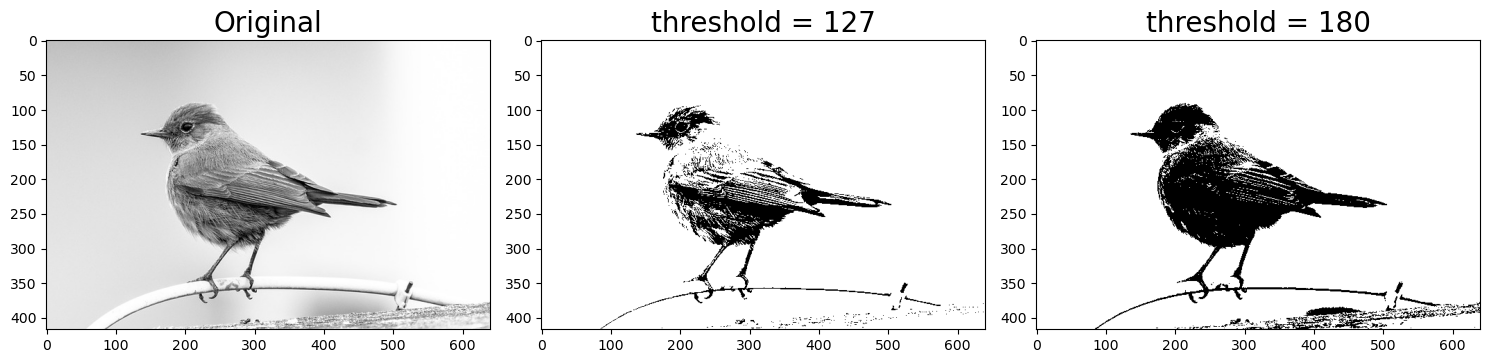

In [2]:
# 以灰階方式讀取圖片
img = cv2.imread('sample/bird.jpg', cv2.IMREAD_GRAYSCALE)

# 設定門檻值為 127，超過門檻設為 255，其餘設為 0
ret, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# 2. 設定不同的門檻值進行測試
# 當像素 > 127 時轉為 255 (白)，其餘為 0 (黑)
ret1, thresh1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# 當像素 > 180 時轉為 255 (白)，其餘為 0 (黑)
ret2, thresh2 = cv2.threshold(img, 180, 255, cv2.THRESH_BINARY)

# 顯示結果
opencv_tools.show_img_by_matplotlib_1x3(
    'Original', img,
    'threshold = 127', thresh1,
    'threshold = 180', thresh2    
)

## 9-2 Otsu 二值化（自動門檻值選取） 

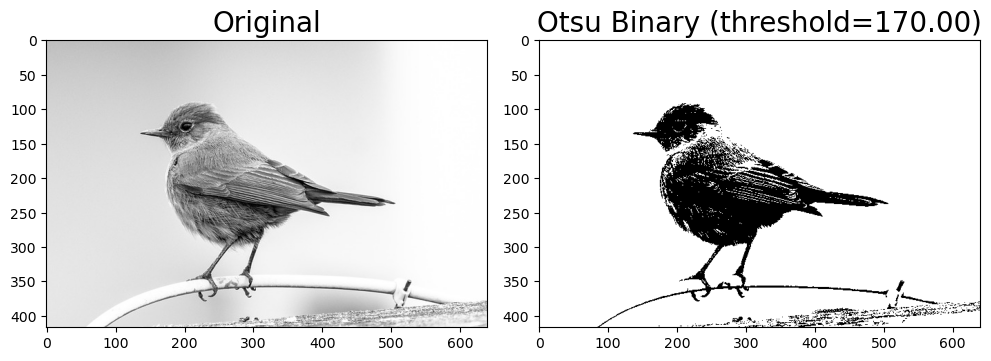

In [3]:
# 讀取灰階影像
img = cv2.imread('sample/bird.jpg', cv2.IMREAD_GRAYSCALE)

# 使用 Otsu 二值化，自動選取最佳門檻值
ret, otsu_binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 顯示結果
opencv_tools.show_img_by_matplotlib_1x2(
    'Original', img,
    f"Otsu Binary (threshold={ret:.2f})", otsu_binary    
)

## 9-3 自適應二值化（Adaptive Thresholding）

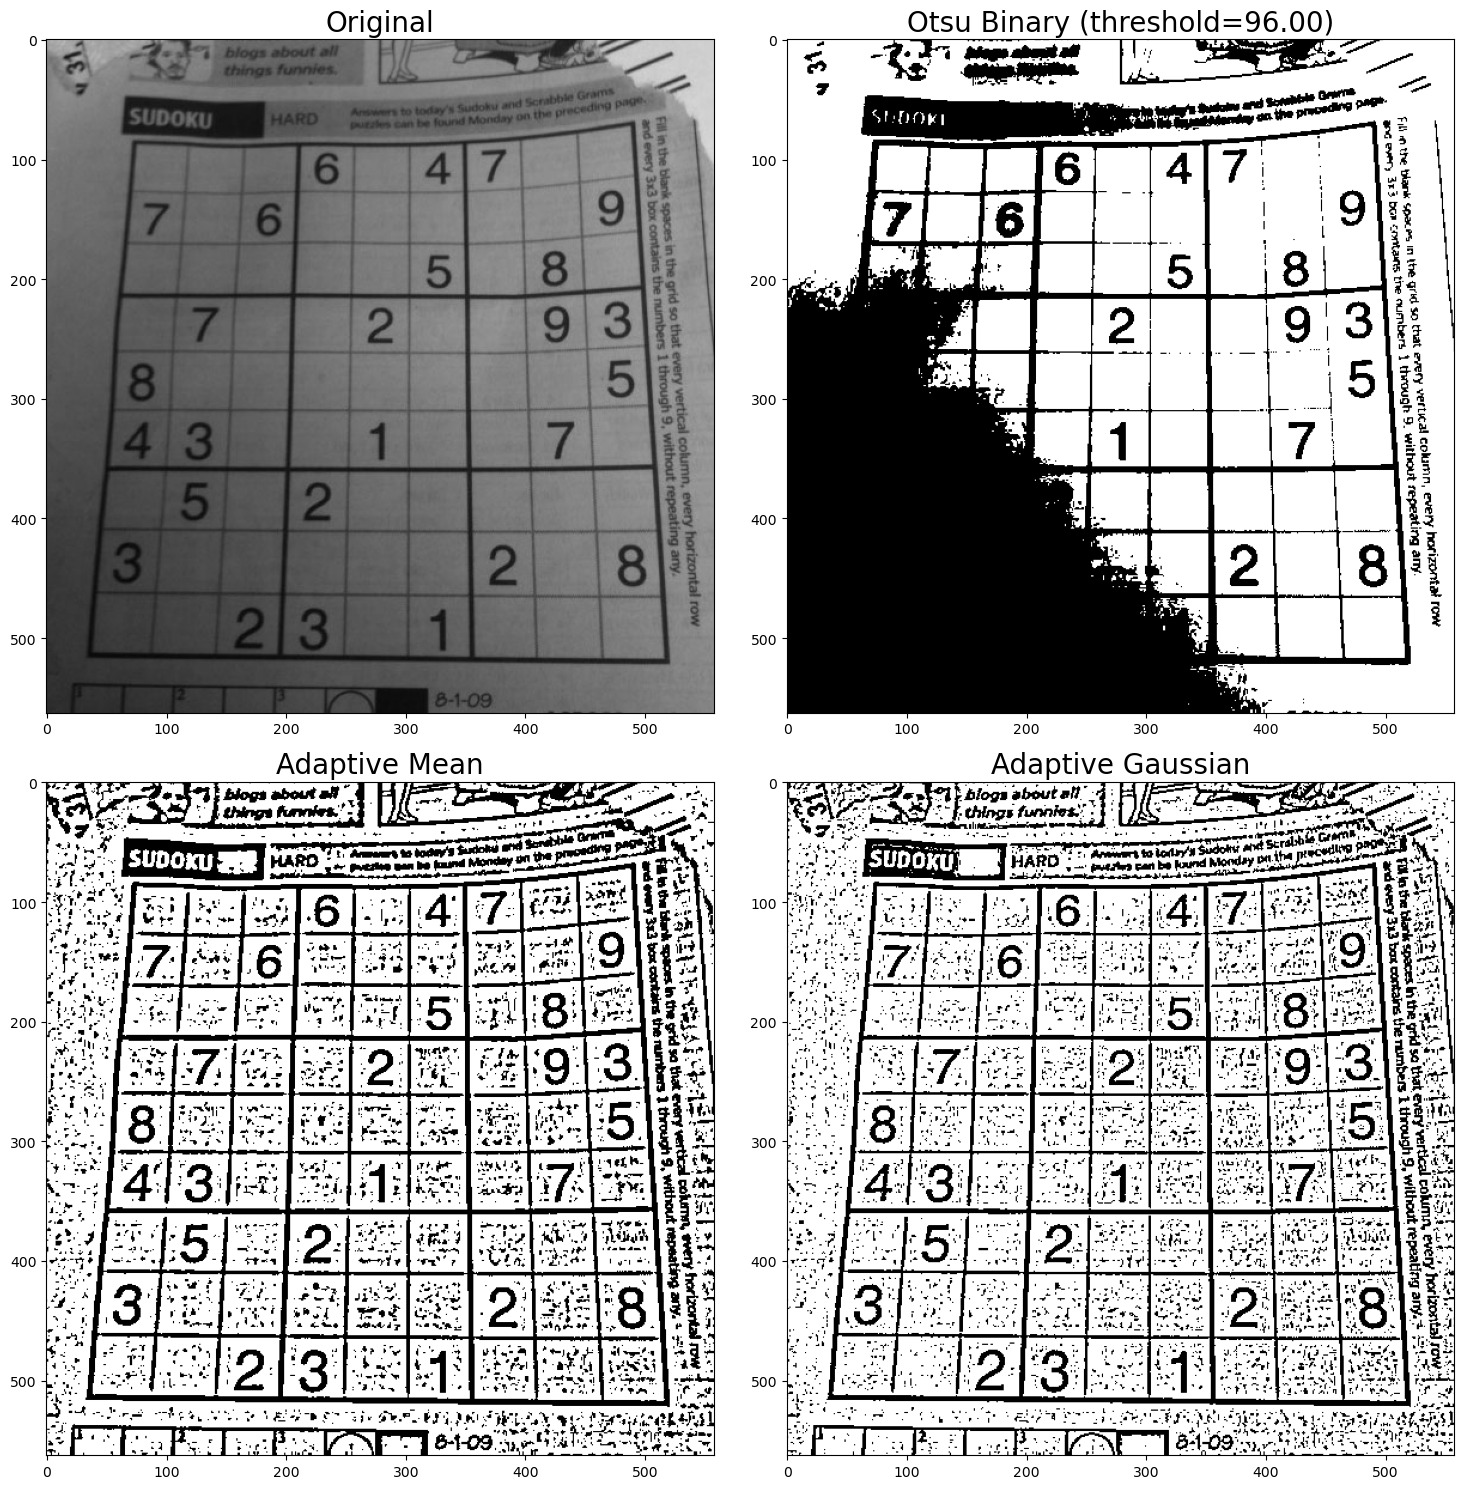

In [4]:
# 讀取灰階影像
img = cv2.imread('sample/sudoku.png', cv2.IMREAD_GRAYSCALE)

# 使用 Otsu 二值化，自動選取最佳門檻值
ret, otsu_binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 自適應均值二值化
adaptive_mean = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)

# 自適應高斯二值化
adaptive_gaussian = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

opencv_tools.show_img_by_matplotlib_2x2(
    "Original", img,
    f"Otsu Binary (threshold={ret:.2f})", otsu_binary,    
    "Adaptive Mean", adaptive_mean, 
    "Adaptive Gaussian", adaptive_gaussian
)

# 9-E 練習：二值化

原圖


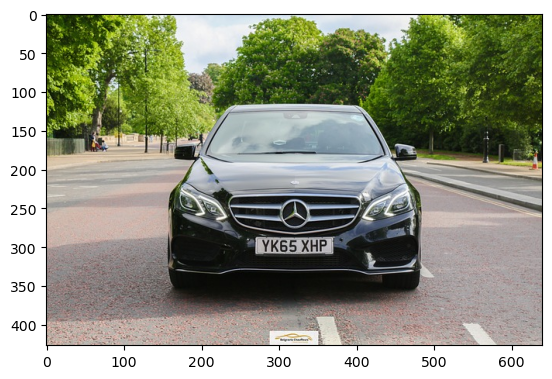

擷取出的車牌


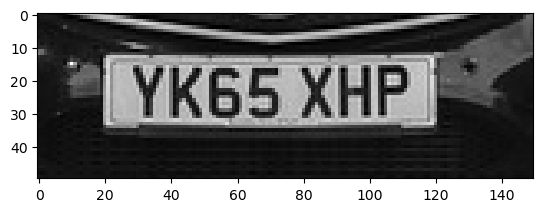

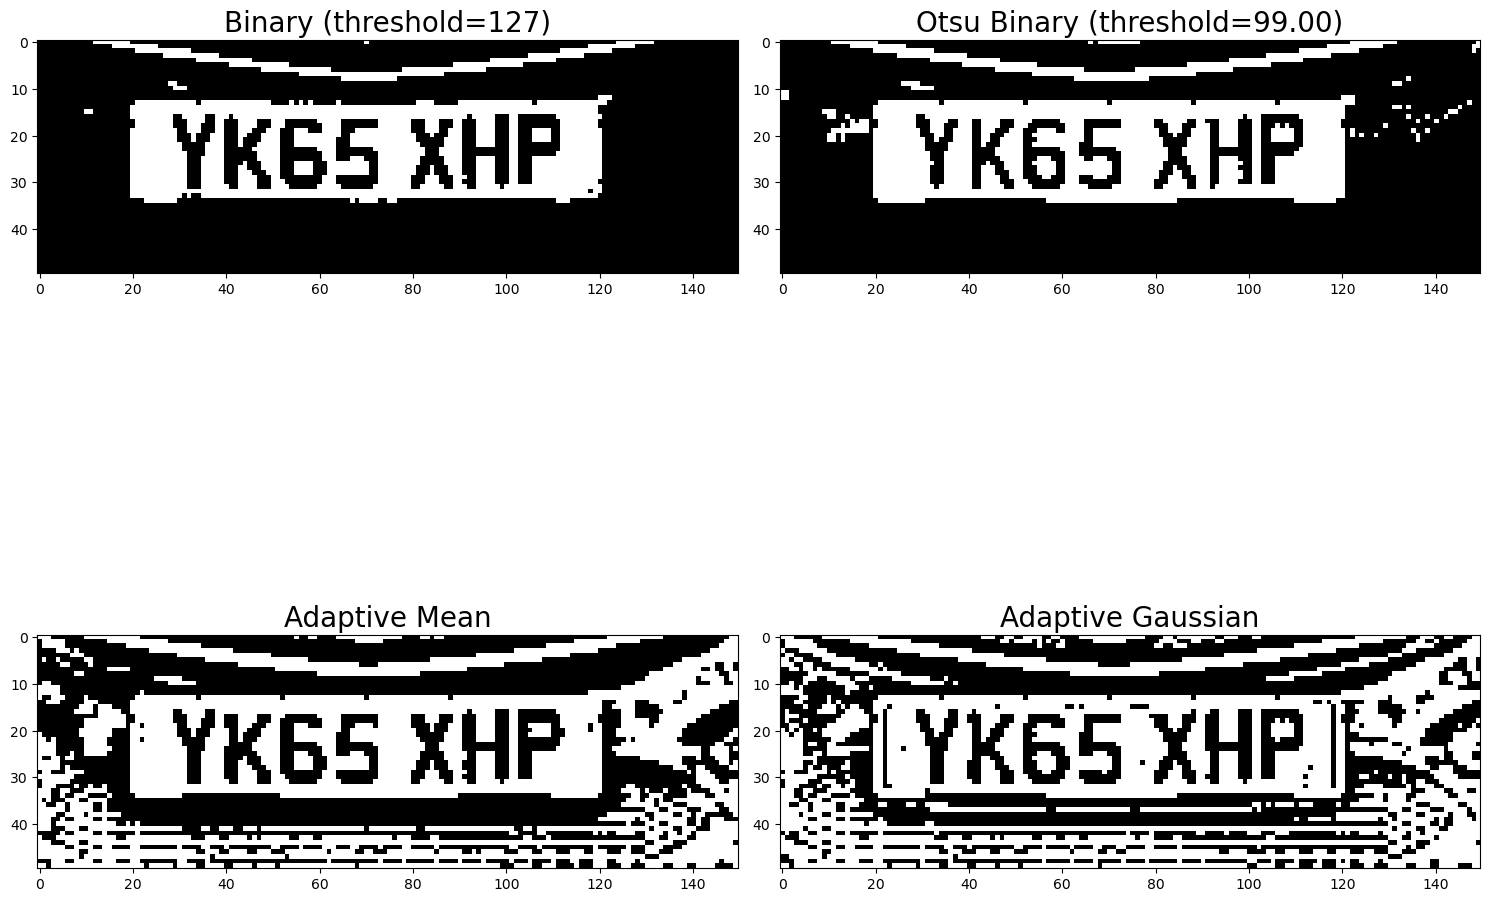

In [5]:
# 讀取影像
img = cv2.imread('sample/car.jpg')

# 轉灰階影像
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 模仿車牌偵測的結果，擷取車牌部分
license_plate = img_gray[275:325,250:400]

# 設定門檻值為 127，超過門檻設為 255，其餘設為 0
ret, binary = cv2.threshold(license_plate, 127, 255, cv2.THRESH_BINARY)

# 使用 Otsu 二值化，自動選取最佳門檻值
ret, otsu_binary = cv2.threshold(license_plate, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 自適應均值二值化
adaptive_mean = cv2.adaptiveThreshold(license_plate, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)

# 自適應高斯二值化
adaptive_gaussian = cv2.adaptiveThreshold(license_plate, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

# 顯示結果
print("原圖")
opencv_tools.show_img_by_matplotlib(img)
print("擷取出的車牌")
opencv_tools.show_img_by_matplotlib(license_plate)
opencv_tools.show_img_by_matplotlib_2x2(
    'Binary (threshold=127)', binary,    
    f"Otsu Binary (threshold={ret:.2f})", otsu_binary,    
    "Adaptive Mean", adaptive_mean, 
    "Adaptive Gaussian", adaptive_gaussian
)